# Modelling data - Version 3

This version includes all variables in the dataset **except for the solar generation variable "SOLAR".**

<div>
Trabajo Integrador<br>
Maestría en Analítica e Inteligencia de Negocios<br>
Universidad del Valle<br>

</div>

#### Student
Camilo Andrés Jaramillo Tarapues - 2402218 

## Libraries

In [1]:
# Libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

## Dataset

In [2]:
# Cargar el conjunto de datos
df = pd.read_csv('../../data/out/dataset_final.csv')
df

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.00,28880.74,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.00,29107.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.00,25939.87,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.00,25651.57,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.00,25245.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025-06-30 19:00:00,2025,6,30,19,112.55,1311491.62,9025510.46,2476.26,88117.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48188,2025-06-30 20:00:00,2025,6,30,20,112.55,1316147.03,8848494.08,1550.03,93431.69,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48189,2025-06-30 21:00:00,2025,6,30,21,106.25,1376475.95,8510792.32,0.00,95167.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48190,2025-06-30 22:00:00,2025,6,30,22,105.55,1401097.29,8058142.03,0.00,99156.29,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63


In [3]:
# Dropping column "SOLAR"

df = df.drop(columns=["SOLAR"])
df.head()

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,28880.74,4291.34,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,29107.37,3511.94,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,25939.87,2641.90,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,25651.57,3032.30,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,25245.37,2514.76,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02


In [4]:
print("Dataset info: ")
print(df.info())

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48192 entries, 0 to 48191
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FECHA_HORA             48192 non-null  object 
 1   YEAR                   48192 non-null  int64  
 2   MONTH                  48192 non-null  int64  
 3   DAY                    48192 non-null  int64  
 4   HORA                   48192 non-null  int64  
 5   PRECIO                 48192 non-null  float64
 6   TERMICA                48192 non-null  float64
 7   HIDRAULICA             48192 non-null  float64
 8   COGENERADOR            48192 non-null  float64
 9   EOLICA                 48192 non-null  float64
 10  NIVEL_ENSO             48192 non-null  float64
 11  FUEL_CONS_ACPM         48192 non-null  float64
 12  FUEL_CONS_CARBON       48192 non-null  float64
 13  FUEL_CONS_COMBUSTOLEO  48192 non-null  float64
 14  FUEL_CONS_CRUDO        48192 non-null  

In [5]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
FECHA_HORA               0
YEAR                     0
MONTH                    0
DAY                      0
HORA                     0
PRECIO                   0
TERMICA                  0
HIDRAULICA               0
COGENERADOR              0
EOLICA                   0
NIVEL_ENSO               0
FUEL_CONS_ACPM           0
FUEL_CONS_CARBON         0
FUEL_CONS_COMBUSTOLEO    0
FUEL_CONS_CRUDO          0
FUEL_CONS_GAS            0
FUEL_CONS_GAS_NI         0
FUEL_CONS_GLP            0
FUEL_COST_CARBON         0
FUEL_COST_GAS            0
FUEL_COST_GAS_NI         0
FUEL_COST_COMBUSTOLEO    0
IPC_VAR_MOM_PCT          0
IPP_VAR_PN_MOM_PCT       0
IPP_VAR_OI_MOM_PCT       0
dtype: int64


**There are no missing values and all data is numeric, so it is ready to train the models.**

## Scale data

In [6]:
# Define target column 'PRECIO'
TARGET_COLUMN = 'PRECIO'

# Variables that are truly categorical even though they are numerical
categorical_numeric = ["YEAR", "MONTH", "DAY", "HORA", "NIVEL_ENSO"]

# Identify the continuous numerical columns that we do scale
numeric_features = [
    col for col in df.columns 
    if col not in categorical_numeric and col != TARGET_COLUMN and col != 'FECHA_HORA'
]

# Preprocessor: We only scale continuous numerics
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough", categorical_numeric)
    ]
)

## Train, test and split data

Dividing the balanced dataset into two subsets: one to train the model8(70% of the data) and another to evaluate it (remainin2 30%

In [7]:
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar el tamaño de cada conjunto
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 23)
Test set size: (9639, 23)


## Baseline Models

In [8]:
# Baseline models evaluation with multiple metrics

# Define dictionary of regression models
random_state=42

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),  # may be slower on large datasets
    "KNN": KNeighborsRegressor(),  # may be slower on large datasets
}

# Define multiple metrics
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "mse": make_scorer(mean_squared_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

In [9]:
results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression -0.672906  176.393096   81163.536841  255.816259
Ridge             -0.672004  176.370934   81150.567927  255.784019
Lasso             -0.325985  165.974105   75762.509555  242.264201
ElasticNet         0.182455  145.411143   62198.270404  211.506116
Decision Tree     -8.451486  244.739184  228674.497900  419.131260
Random Forest     -2.661090  195.486909  127853.606288  313.598989
Gradient Boosting -0.649388  163.558300   89567.026154  249.589071
SVR               -0.671079  232.611864  131117.844221  304.198179
KNN               -0.221858  160.683364   76123.114838  241.045997


In [10]:
#                         r2         mae            mse        rmse
#Linear Regression -0.674345  176.143089   81073.484241  255.868922
#Ridge             -0.673436  176.120759   81060.409212  255.836226
#Lasso             -0.325634  165.753530   75625.847518  242.202735
#ElasticNet         0.185139  145.374287   62001.490904  211.163299
#Decision Tree     -3.449350  228.943037  184205.415683  378.558964
#Random Forest     -2.352729  192.978591  125518.982163  309.732879
#Gradient Boosting -0.639346  162.598554   89007.378341  248.218739
#SVR               -0.671078  232.611620  131116.991248  304.197465
#KNN               -0.225339  161.433940   77056.569938  242.010131

### GridSearch CV

In [11]:
# Define hiperparameters
param_grids = {
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "RandomForest": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7]
    }
}

# Define models
models = {
    "ElasticNet": ElasticNet(max_iter=10000, random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [12]:
# Para guardar resultados
best_models = {}
results = {}

for name, model in models.items():
    print("************************************************")
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X, y)
    
    best_models[name] = grid.best_estimator_
    results[name] = {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    }
    print(f"Model: {name}")
    print(f"Best score: {grid.best_score_}")
    print(f"Best params: {grid.best_params_}")
    
results

************************************************
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Model: ElasticNet
Best score: 0.2066491020847089
Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
************************************************
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model: RandomForest
Best score: -2.118648531704878
Best params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 300}
************************************************
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Model: GradientBoosting
Best score: -0.46711645516802147
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}


{'ElasticNet': {'best_score': 0.2066491020847089,
  'best_params': {'model__alpha': 10, 'model__l1_ratio': 0.9}},
 'RandomForest': {'best_score': -2.118648531704878,
  'best_params': {'model__max_depth': 10,
   'model__min_samples_split': 2,
   'model__n_estimators': 300}},
 'GradientBoosting': {'best_score': -0.46711645516802147,
  'best_params': {'model__learning_rate': 0.1,
   'model__max_depth': 3,
   'model__n_estimators': 500}}}

In [13]:
#************************************************
#Fitting 5 folds for each of 30 candidates, totalling 150 fits
#Model: ElasticNet
#Best score: 0.2076746414849791
#Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
#************************************************
#Fitting 5 folds for each of 36 candidates, totalling 180 fits
#Model: RandomForest
#Best score: -2.109574974486729
#Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
#************************************************
#Fitting 5 folds for each of 27 candidates, totalling 135 fits
#Model: GradientBoosting
#Best score: -0.46319237914950817
#Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}

### Boost models

In [14]:
robust_models = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

In [15]:
robust_results = {}

for name, model in robust_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    robust_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

pd.DataFrame(robust_results).T

,r2,mae,mse,rmse
XGBoost,-0.796015,178.707756,117711.620915,287.725822
LightGBM,-0.765358,160.716807,91840.270566,257.599975
CatBoost,-0.441436,160.795289,86172.623716,246.862396


## Time Series Forecasting

### Splits the training and test sets as a time series

In [16]:
# Separar variables y target
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Usar el índice para cortar: primeras 80% filas = train, últimas 20% filas = test
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 23)
Test set size: (9639, 23)


In [17]:
# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression -1.226963  171.437434   68868.569657  245.150224
Ridge             -1.135900  170.742332   68547.915304  244.092940
Lasso             -0.005002  155.138784   62781.830251  221.095685
ElasticNet        -0.139606  161.104308   69056.954580  230.217601
Decision Tree     -0.277938  181.717138  103623.899861  262.657855
Random Forest     -0.156619  169.168449   92994.970353  248.655755
Gradient Boosting -0.226463  164.497213   89163.677974  243.513023
SVR               -1.181564  252.495192  155958.802983  338.512916
KNN               -0.419115  179.638650   83694.512369  255.594390


### Prophet

In [18]:
# Prepare data for Prophet: needs 'ds' (date) and 'y' (target)

df_prophet = df.copy()
df_prophet = df_prophet.drop(columns=["YEAR", "MONTH", "DAY", "HORA"])
df_prophet.head()

,FECHA_HORA,PRECIO,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,NIVEL_ENSO,FUEL_CONS_ACPM,FUEL_CONS_CARBON,FUEL_CONS_COMBUSTOLEO,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,72.02,2109637.93,4418103.51,28880.74,4291.34,1.0,0.0,234788.670155,0.0,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,136.71,1864989.80,4548853.97,29107.37,3511.94,1.0,0.0,234788.670155,0.0,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,127.71,1720883.01,4525898.75,25939.87,2641.90,1.0,0.0,234788.670155,0.0,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,127.71,1649014.61,4458645.56,25651.57,3032.30,1.0,0.0,234788.670155,0.0,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,127.71,1711745.36,4279657.90,25245.37,2514.76,1.0,0.0,234788.670155,0.0,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02


20:35:12 - cmdstanpy - INFO - Chain [1] start processing
20:36:35 - cmdstanpy - INFO - Chain [1] done processing


Prophet Forecasting Results:
MAE: 266.23, RMSE: 450.33, R2: 0.19


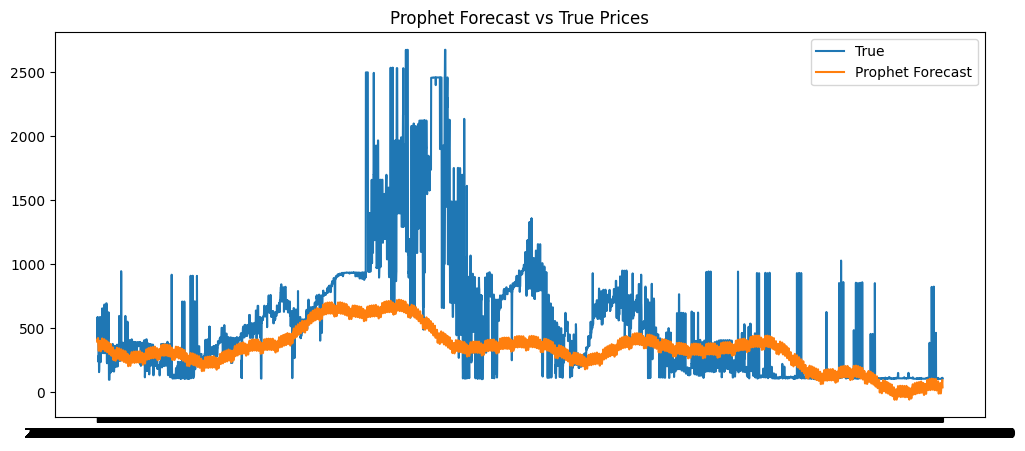

In [19]:
df_prophet = df_prophet.reset_index()[["FECHA_HORA", "PRECIO"]].rename(columns={"FECHA_HORA": "ds", "PRECIO": "y"})

# Train/test split: last 20% as test
train_size = int(len(df_prophet) * 0.8)
train_df, test_df = df_prophet.iloc[:train_size], df_prophet.iloc[train_size:]

# Fit Prophet model
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
prophet.fit(train_df)

# Forecast over test period
future = prophet.make_future_dataframe(periods=len(test_df), freq="h")
forecast = prophet.predict(future)

# Extract predictions only for test period
pred_prophet = forecast.set_index("ds").loc[test_df["ds"], "yhat"]

# Metrics
mae_p = mean_absolute_error(test_df["y"], pred_prophet)
rmse_p = root_mean_squared_error(test_df["y"], pred_prophet)
r2 = r2_score(test_df["y"], pred_prophet)

print("Prophet Forecasting Results:")
print(f"MAE: {mae_p:.2f}, RMSE: {rmse_p:.2f}, R2: {r2:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(test_df["ds"], test_df["y"], label="True")
plt.plot(test_df["ds"], pred_prophet, label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast vs True Prices")
plt.show()

### Ensemble Prophet + XGBoost

XGBoost with Prophet feature:
MAE: 246.11, RMSE: 434.51, R2: 0.25


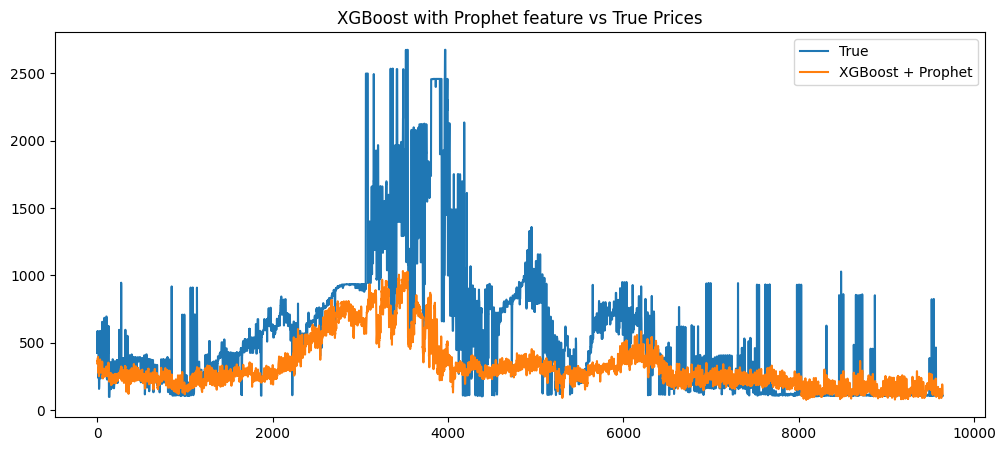

In [20]:
# --- Use Prophet as a feature for XGBoost ---

X_full = df.copy().drop(columns=["FECHA_HORA"])

# Add propehet prediction as a new column
X_full["prophet_yhat"] = forecast.set_index("ds")["yhat"].values

# Define train/test (temporal split)
X_train = X_full.iloc[:train_size].drop(columns=["PRECIO"])
y_train = X_full.iloc[:train_size]["PRECIO"]
X_test = X_full.iloc[train_size:].drop(columns=["PRECIO"])
y_test = X_full.iloc[train_size:]["PRECIO"]

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=500, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# --- Metrics ---
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost with Prophet feature:")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# --- Paso 5: Graficamos ---
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="True")
plt.plot(y_pred_xgb, label="XGBoost + Prophet")
plt.legend()
plt.title("XGBoost with Prophet feature vs True Prices")
plt.show()

## Train and test with lags

In [21]:
# --- Create lag features ---
def create_lags(df, target_col, n_lags=24):
    df_lagged = df.copy()
    for lag in range(1, n_lags+1):
        df_lagged[f"{target_col}_lag{lag}"] = df_lagged[target_col].shift(lag)
    return df_lagged.dropna()

df_lagged = create_lags(df, target_col="PRECIO", n_lags=24)
df_lagged = df_lagged.dropna()

# Features (all except date & target)
X = df_lagged.drop(columns=["FECHA_HORA", "PRECIO"])
y = df_lagged["PRECIO"]

# --- Train/Test split ---
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [22]:
X_train.head()

,YEAR,MONTH,DAY,HORA,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,NIVEL_ENSO,FUEL_CONS_ACPM,...,PRECIO_lag15,PRECIO_lag16,PRECIO_lag17,PRECIO_lag18,PRECIO_lag19,PRECIO_lag20,PRECIO_lag21,PRECIO_lag22,PRECIO_lag23,PRECIO_lag24
24,2020,1,2,0,1608662.67,4585681.98,19184.34,4908.48,1.0,431.0,...,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71,72.02
25,2020,1,2,1,1508655.14,4466153.60,19342.06,3836.61,1.0,431.0,...,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71
26,2020,1,2,2,1413968.65,4520386.10,20345.52,5343.35,1.0,431.0,...,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71
27,2020,1,2,3,1369278.08,4470436.67,21123.41,3942.81,1.0,431.0,...,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71
28,2020,1,2,4,1353049.36,4558570.93,25773.80,2363.15,1.0,431.0,...,136.71,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71


### XGBoost Forecasting with Lags

XGBoost Forecasting Results:
MAE: 92.21, RMSE: 255.80, R2: 0.74


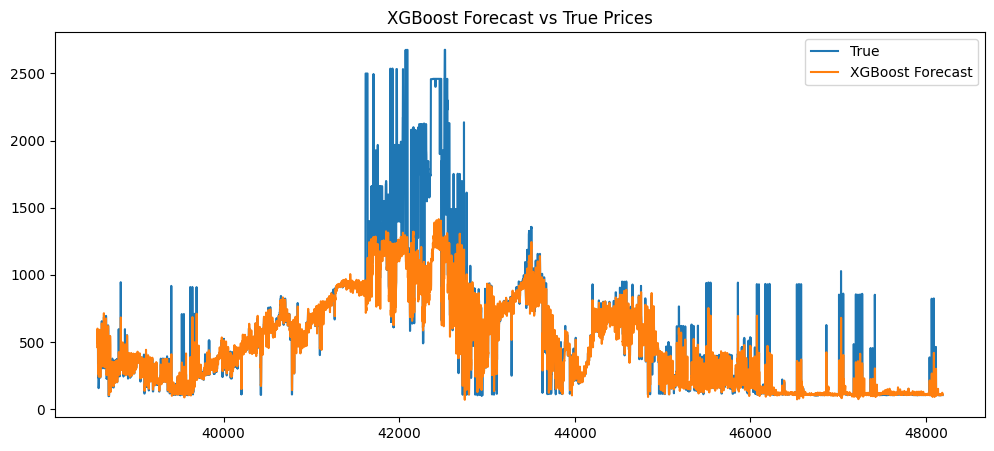

In [23]:
# ===========================================
# XGBoost Forecasting with Lags
# ===========================================

# Train XGBoost
model_xgb = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.1, max_depth=6)
model_xgb.fit(X_train, y_train)

# Predictions
pred_xgb = model_xgb.predict(X_test)

# Metrics
mae_x = mean_absolute_error(y_test, pred_xgb)
rmse_x = root_mean_squared_error(y_test, pred_xgb)
r2_x = r2_score(y_test, pred_xgb)

print("XGBoost Forecasting Results:")
print(f"MAE: {mae_x:.2f}, RMSE: {rmse_x:.2f}, R2: {r2_x:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="True")
plt.plot(y_test.index, pred_xgb, label="XGBoost Forecast")
plt.legend()
plt.title("XGBoost Forecast vs True Prices")
plt.show()

### Boosting with lags

In [24]:
models = {
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
}

In [25]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

df_results = pd.DataFrame(results).T
print(df_results)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003689 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9760
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 47
[LightGBM] [Info] Start training from score 318.370624
                MAE        RMSE        R2
XGBoost   93.098995  256.977551  0.737339
LightGBM  81.938154  227.001126  0.795044
CatBoost  82.565434  226.746446  0.795504


### Boosting with lags (tunning)

In [26]:
# ===================== OBJECTIVES =====================

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }

    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = LGBMRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1)
    }

    model = CatBoostRegressor(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE

In [27]:
# ===================== RUN STUDIES =====================

studies = {}
for name, objective in [("XGBoost", objective_xgb), 
                        ("LightGBM", objective_lgbm), 
                        ("CatBoost", objective_cat)]:
    print(f"Running Optuna for {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100)  # puedes subir n_trials si quieres
    studies[name] = study
    print(f"Best params for {name}: {study.best_trial.params}")
    print(f"Best RMSE: {study.best_value:.4f}\n")


# ===================== FINAL EVALUATION =====================

results = {}
best_params = {}
best_scores = {}

for name, study in studies.items():
    if name == "XGBoost":
        model = XGBRegressor(**study.best_trial.params, random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        model = LGBMRegressor(**study.best_trial.params, random_state=42)
    else:
        model = CatBoostRegressor(**study.best_trial.params, random_state=42, verbose=0)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    best_params[name] = study.best_trial.params
    best_scores[name] = study.best_value
    
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": root_mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }


[I 2025-08-26 20:39:05,457] A new study created in memory with name: no-name-faed4923-bd28-4451-9efd-11ff8808066a


Running Optuna for XGBoost...


[I 2025-08-26 20:39:33,484] Trial 0 finished with value: 263.1219366549965 and parameters: {'n_estimators': 532, 'learning_rate': 0.07341749864175283, 'max_depth': 12, 'subsample': 0.7858210787433595, 'colsample_bytree': 0.7977776150657344, 'gamma': 4.328657498799236, 'reg_alpha': 1.8208376019703514, 'reg_lambda': 2.222065488066555}. Best is trial 0 with value: 263.1219366549965.
[I 2025-08-26 20:39:36,868] Trial 1 finished with value: 225.68911870183442 and parameters: {'n_estimators': 577, 'learning_rate': 0.03411538517374874, 'max_depth': 4, 'subsample': 0.972184268310294, 'colsample_bytree': 0.695143819950843, 'gamma': 1.559807699049498, 'reg_alpha': 2.0488086350297547, 'reg_lambda': 4.5544658185007325}. Best is trial 1 with value: 225.68911870183442.
[I 2025-08-26 20:40:28,982] Trial 2 finished with value: 256.3048359214307 and parameters: {'n_estimators': 881, 'learning_rate': 0.0286274132719589, 'max_depth': 12, 'subsample': 0.9180005810654646, 'colsample_bytree': 0.954716497002

Best params for XGBoost: {'n_estimators': 1154, 'learning_rate': 0.010028779531038255, 'max_depth': 3, 'subsample': 0.742777471250948, 'colsample_bytree': 0.678884091407866, 'gamma': 1.45851772745594, 'reg_alpha': 1.0194150894531684, 'reg_lambda': 3.07393132668087}
Best RMSE: 218.2130

Running Optuna for LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007677 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9760
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 47
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

[I 2025-08-26 20:55:15,200] Trial 0 finished with value: 227.55616736520997 and parameters: {'n_estimators': 234, 'learning_rate': 0.012596356567858734, 'num_leaves': 290, 'max_depth': 9, 'min_child_samples': 94, 'subsample': 0.6635969160255313, 'colsample_bytree': 0.8042817051239771}. Best is trial 0 with value: 227.55616736520997.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9760
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 47
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

[I 2025-08-26 21:03:10,195] Trial 99 finished with value: 214.4073359861767 and parameters: {'n_estimators': 207, 'learning_rate': 0.0441150482498587, 'num_leaves': 112, 'max_depth': 3, 'min_child_samples': 90, 'subsample': 0.8352795939274172, 'colsample_bytree': 0.8598048228333763}. Best is trial 97 with value: 213.7455881196902.
[I 2025-08-26 21:03:10,195] A new study created in memory with name: no-name-5791b818-1046-4e2d-a41a-9b2cdc4b04b0


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best params for LightGBM: {'n_estimators': 206, 'learning_rate': 0.04266611912193186, 'num_leaves': 116, 'max_depth': 3, 'min_child_samples': 90, 'subsample': 0.8524164155081564, 'colsample_bytree': 0.8833405078835046}
Best RMSE: 213.7456

Running Optuna for CatBoost...


[I 2025-08-26 21:05:53,951] Trial 0 finished with value: 247.04532548688937 and parameters: {'iterations': 1091, 'learning_rate': 0.2500808701774823, 'depth': 10, 'l2_leaf_reg': 5.045154373817028, 'bagging_temperature': 0.48742520124532285}. Best is trial 0 with value: 247.04532548688937.
[I 2025-08-26 21:06:01,107] Trial 1 finished with value: 219.62308216139823 and parameters: {'iterations': 841, 'learning_rate': 0.04883224078202692, 'depth': 3, 'l2_leaf_reg': 2.128737929881174, 'bagging_temperature': 0.07196915922356395}. Best is trial 1 with value: 219.62308216139823.
[I 2025-08-26 21:06:16,835] Trial 2 finished with value: 222.4823800571945 and parameters: {'iterations': 1199, 'learning_rate': 0.02609166513878283, 'depth': 5, 'l2_leaf_reg': 3.560033189661992, 'bagging_temperature': 0.9647882231177843}. Best is trial 1 with value: 219.62308216139823.
[I 2025-08-26 21:06:46,681] Trial 3 finished with value: 238.53929244059563 and parameters: {'iterations': 1306, 'learning_rate': 0.1

Best params for CatBoost: {'iterations': 589, 'learning_rate': 0.05397932406942757, 'depth': 3, 'l2_leaf_reg': 6.457373050373363, 'bagging_temperature': 0.3540858243636887}
Best RMSE: 214.5196

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9760
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 47
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

In [28]:
params_df = pd.DataFrame(best_params).T
params_df["Best_RMSE"] = pd.Series(best_scores)
results_df = pd.DataFrame(results).T

print("\n===== Best Hyperparameters per Model =====")
print(params_df)
print(results_df)


===== Best Hyperparameters per Model =====
          n_estimators  learning_rate  max_depth  subsample  colsample_bytree  \
XGBoost         1154.0       0.010029        3.0   0.742777          0.678884   
LightGBM         206.0       0.042666        3.0   0.852416          0.883341   
CatBoost           NaN       0.053979        NaN        NaN               NaN   

             gamma  reg_alpha  reg_lambda  num_leaves  min_child_samples  \
XGBoost   1.458518   1.019415    3.073931         NaN                NaN   
LightGBM       NaN        NaN         NaN       116.0               90.0   
CatBoost       NaN        NaN         NaN         NaN                NaN   

          iterations  depth  l2_leaf_reg  bagging_temperature   Best_RMSE  
XGBoost          NaN    NaN          NaN                  NaN  218.213048  
LightGBM         NaN    NaN          NaN                  NaN  213.745588  
CatBoost       589.0    3.0     6.457373             0.354086  214.519601  
                MAE   

### Baseline models with lag

In [29]:
# Entrenar cada modelo base con cross-validation
results_base = {}

# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

for name, model in baseline_models.items():
    scores = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results_base[name] = {
        metric: np.mean(scores[f"test_{metric}"]) for metric in scoring.keys()
    }

# Mostrar resultados
results_base_df = pd.DataFrame(results_base).T
print(results_base_df)

                         r2         mae           mse        rmse
Linear Regression  0.949180   26.224266   4540.825031   55.512019
Ridge              0.949294   26.207367   4540.420267   55.497326
Lasso              0.950643   25.693207   4528.868537   55.239825
ElasticNet         0.950351   25.765290   4531.507997   55.285663
Decision Tree      0.574847   82.341551  44155.619124  166.833482
Random Forest      0.809062   57.568016  25055.434506  119.362634
Gradient Boosting  0.841165   51.908525  26185.831062  114.595713
SVR               -0.081871  182.780519  89517.389252  255.228756
KNN                0.090609  151.708990  67380.386909  224.689126


### Baseline models (linear) with lag (tunning)

In [30]:
# ========================
# Setting
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

# Scorers
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

# ========================
# Linear models → GridSearchCV
# ========================

linear_grids = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso": (Lasso(max_iter=5000), {"alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "ElasticNet": (ElasticNet(max_iter=5000), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
}

In [31]:
results = {}

for name, (model, grid) in linear_grids.items():
    search = GridSearchCV(
        model,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1
    )
    search.fit(X, y)
    best_model = search.best_estimator_

    # Cross-validate with multiple metrics
    scores = cross_val_score(best_model, X, y, cv=tscv, scoring="r2")
    r2 = scores.mean()
    scores_mae = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
    mae = -scores_mae.mean()
    scores_rmse = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    rmse = -scores_rmse.mean()

    results[name] = {
        "Best Params": search.best_params_,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_results = pd.DataFrame(results).T
df_results

,Best Params,R2,MAE,RMSE
Linear Regression,{},0.94918,26.224266,55.512019
Ridge,{'alpha': 100},0.949937,26.064504,55.402588
Lasso,{'alpha': 10},0.951006,25.594773,55.165983
ElasticNet,"{'alpha': 10, 'l1_ratio': 0.9}",0.951013,25.599992,55.168566


In [32]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959

### Baseline models (non-linear) with lag (tunning)

In [33]:
# ========================
# Non-linear models → Optuna
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

def optuna_objective(trial, model_name):
    
    if model_name == "Decision Tree":
        model = DecisionTreeRegressor(
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            random_state=42
        )

    elif model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            n_jobs=-1, random_state=42
        )

    elif model_name == "Gradient Boosting":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 10),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            random_state=42
        )

    # CV RMSE
    scores = cross_val_score(model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    return -scores.mean()

In [34]:
nonlinear_models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

In [35]:
nonlinear_results = {}

for name in nonlinear_models:
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: optuna_objective(trial, name), n_trials=30, n_jobs=-1)

    best_params = study.best_params

    # Entrenar con los mejores parámetros
    if name == "Decision Tree":
        best_model = DecisionTreeRegressor(**best_params, random_state=42)
    elif name == "Random Forest":
        best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=42)
    elif name == "Gradient Boosting":
        best_model = GradientBoostingRegressor(**best_params, random_state=42)

    # Cross-validate with metrics
    r2 = cross_val_score(best_model, X, y, cv=tscv, scoring="r2").mean()
    mae = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error").mean()
    rmse = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error").mean()

    nonlinear_results[name] = {
        "Best Params": best_params,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_nonlinear_results = pd.DataFrame(nonlinear_results).T
df_nonlinear_results

[I 2025-08-26 21:59:03,348] A new study created in memory with name: no-name-82fffc28-a5bf-4fe0-a76a-582e8ee94c8c
[I 2025-08-26 21:59:09,181] Trial 4 finished with value: 123.6269120457548 and parameters: {'max_depth': 3, 'min_samples_split': 19}. Best is trial 4 with value: 123.6269120457548.
[I 2025-08-26 21:59:10,779] Trial 3 finished with value: 101.2828353287379 and parameters: {'max_depth': 4, 'min_samples_split': 12}. Best is trial 3 with value: 101.2828353287379.
[I 2025-08-26 21:59:12,884] Trial 0 finished with value: 98.27074056138812 and parameters: {'max_depth': 5, 'min_samples_split': 4}. Best is trial 0 with value: 98.27074056138812.
[I 2025-08-26 21:59:12,932] Trial 10 finished with value: 98.27074056138812 and parameters: {'max_depth': 5, 'min_samples_split': 13}. Best is trial 0 with value: 98.27074056138812.
[I 2025-08-26 21:59:13,043] Trial 5 finished with value: 98.27074056138812 and parameters: {'max_depth': 5, 'min_samples_split': 12}. Best is trial 0 with value: 

,Best Params,R2,MAE,RMSE
Decision Tree,"{'max_depth': 5, 'min_samples_split': 4}",0.854743,46.933357,98.270741
Random Forest,"{'n_estimators': 714, 'max_depth': 5, 'min_sam...",0.798644,59.173294,114.197158
Gradient Boosting,"{'n_estimators': 886, 'learning_rate': 0.00528...",0.817598,54.227012,116.295477


In [36]:
nonlinear_results

{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 4},
  'R2': 0.8547428594776794,
  'MAE': 46.93335746828882,
  'RMSE': 98.27074056138812},
 'Random Forest': {'Best Params': {'n_estimators': 714,
   'max_depth': 5,
   'min_samples_split': 13,
   'max_features': 'log2'},
  'R2': 0.7986443760858788,
  'MAE': 59.17329434046262,
  'RMSE': 114.19715784965392},
 'Gradient Boosting': {'Best Params': {'n_estimators': 886,
   'learning_rate': 0.005281721039012774,
   'max_depth': 5,
   'subsample': 0.8951938652805667},
  'R2': 0.8175981094793275,
  'MAE': 54.22701223926008,
  'RMSE': 116.29547679075817}}

In [37]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959
#Decision Tree	{'max_depth': 5, 'min_samples_split': 8}	0.852894	47.07064	98.828144
#Random Forest	{'n_estimators': 380, 'max_depth': 5, 'min_samples_split': 7,'max_features': None}	0.875931	44.651063	97.202218

In [38]:
# Random forest
#{'Best Params': {'n_estimators': 380,
#  'max_depth': 5,
#  'min_samples_split': 7,
#  'max_features': None},
# 'R2': 0.8759310854350622,
# 'MAE': 44.6510629713005,
# 'RMSE': 97.20221800266624}

In [39]:
#{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 17},
#  'R2': 0.8528940981487452,
#  'MAE': 47.07063996534437,
#  'RMSE': 98.82814400209875},
# 'Random Forest': {'Best Params': {'n_estimators': 407,
#   'max_depth': 4,
#   'min_samples_split': 16,
#   'max_features': None},
#  'R2': 0.8626976844486611,
#  'MAE': 47.776218604543374,
#  'RMSE': 101.92848807043003},
# 'Gradient Boosting': {'Best Params': {'n_estimators': 710,
#   'learning_rate': 0.004824184299163144,
#   'max_depth': 2,
#   'subsample': 0.54752888994856},
#  'R2': 0.8518062305030419,
#  'MAE': 50.53916588389959,
#  'RMSE': 103.0669818471433}}

results 0 with value: 98.0681054649906.

### Other robust models

In [40]:
# Nuevos modelos robustos
new_models = {
    "Extra Trees": ExtraTreesRegressor(n_jobs=-1, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(random_state=42, max_iter=500)
}

In [41]:
# Evaluación
results_new = {}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

for name, model in new_models.items():
    pipe = Pipeline(steps=[("model", model)])
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results_new[name] = {metric: abs(scores[f"test_{metric}"].mean()) if metric != "r2"
                         else scores[f"test_{metric}"].mean()
                         for metric in scoring.keys()}

df_results_new = pd.DataFrame(results_new).T
print(df_results_new)

                                r2          mae           mse         rmse
Extra Trees               0.901240    38.360554  1.574608e+04    85.473232
Hist Gradient Boosting    0.912399    35.295600  1.211520e+04    78.927245
MLP Regressor          -644.521861  3009.613969  1.495302e+07  3397.906553


<hr>

## Long short-term memory (LSTM)

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [43]:
# Numerical variables
print(numeric_features)

['TERMICA', 'HIDRAULICA', 'COGENERADOR', 'EOLICA', 'FUEL_CONS_ACPM', 'FUEL_CONS_CARBON', 'FUEL_CONS_COMBUSTOLEO', 'FUEL_CONS_CRUDO', 'FUEL_CONS_GAS', 'FUEL_CONS_GAS_NI', 'FUEL_CONS_GLP', 'FUEL_COST_CARBON', 'FUEL_COST_GAS', 'FUEL_COST_GAS_NI', 'FUEL_COST_COMBUSTOLEO', 'IPC_VAR_MOM_PCT', 'IPP_VAR_PN_MOM_PCT', 'IPP_VAR_OI_MOM_PCT']


In [44]:
# Scale numerical variables

# ============================
# 1. Prepare data
# ============================

scaler = MinMaxScaler()
df_scaled = df.copy().drop(columns=["FECHA_HORA"])
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])
df_scaled

,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,NIVEL_ENSO,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020,1,1,0,72.02,0.363247,0.269862,0.189648,0.100633,1.0,...,0.419581,0.000000,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597
1,2020,1,1,1,136.71,0.310187,0.286300,0.191136,0.082356,1.0,...,0.419581,0.000000,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597
2,2020,1,1,2,127.71,0.278933,0.283414,0.170337,0.061953,1.0,...,0.419581,0.000000,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597
3,2020,1,1,3,127.71,0.263346,0.274959,0.168444,0.071108,1.0,...,0.419581,0.000000,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597
4,2020,1,1,4,127.71,0.276951,0.252457,0.165776,0.058972,1.0,...,0.419581,0.000000,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025,6,30,19,112.55,0.190143,0.849097,0.578630,0.547735,0.0,...,0.059990,0.316984,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791
48188,2025,6,30,20,112.55,0.191153,0.826843,0.613528,0.549004,0.0,...,0.059990,0.316984,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791
48189,2025,6,30,21,106.25,0.204237,0.784387,0.624925,0.546028,0.0,...,0.059990,0.316984,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791
48190,2025,6,30,22,105.55,0.209577,0.727481,0.651119,0.546691,0.0,...,0.059990,0.316984,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791


In [45]:
# ============================
# 2. Create sequences for LSTM
# ============================

def create_sequences(data, target_col="PRECIO", window_size=24):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:(i + window_size)].values)
        y.append(data.iloc[i + window_size, target_idx])
    
    return np.array(X), np.array(y)

look_back = 48  # last 24 hours
X, y = create_sequences(df_scaled, target_col="PRECIO", window_size=look_back)

print("X shape:", X.shape)  # (samples, timesteps, features)
print("y shape:", y.shape)

X shape: (48144, 48, 24)
y shape: (48144,)


In [46]:
# ============================
# 3. Train-Test split (time series, not random)
# ============================
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [47]:
# ============================
# 4. Model construction (Multivariate - Single step)
# ============================

n_features = X_train.shape[2]  # Número total de variables predictoras

model = Sequential()
model.add(LSTM(128, activation='tanh', return_sequences=True, input_shape=(look_back, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # salida para regresión

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping (para evitar sobreentrenamiento)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 48, 128)           78336     
                                                                 
 dropout (Dropout)           (None, 48, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 129857 (507.25 KB)
Trainable params: 129

In [48]:
# ============================
# 5. Train model

# ============================

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


482/482 [==============================] - 92s 180ms/step - loss: 42509.5938 - mae: 149.8102 - val_loss: 259770.8594 - val_mae: 430.2954
Epoch 2/50
482/482 [==============================] - 81s 169ms/step - loss: 21473.8750 - mae: 105.6978 - val_loss: 179953.9375 - val_mae: 341.1787
Epoch 3/50
482/482 [==============================] - 87s 180ms/step - loss: 8297.0332 - mae: 58.5877 - val_loss: 102915.5547 - val_mae: 234.3986
Epoch 4/50
482/482 [==============================] - 85s 176ms/step - loss: 5729.8721 - mae: 51.3852 - val_loss: 84343.1250 - val_mae: 202.9840
Epoch 5/50
482/482 [==============================] - 84s 175ms/step - loss: 4509.7861 - mae: 46.6563 - val_loss: 70603.0859 - val_mae: 186.0106
Epoch 6/50
482/482 [==============================] - 84s 173ms/step - loss: 4037.1548 - mae: 43.2415 - val_loss: 56748.9609 - val_mae: 168.0228
Epoch 7/50
482/482 [==============================] - 84s 173ms/step - loss: 3657.0386 - mae: 41.2620 - val_loss: 47042.0

In [49]:

# ============================
# 6. Evaluation
# ============================

y_pred = model.predict(X_test)

y_test_inv = y_test
y_pred_inv = y_pred.flatten()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"R2: {r2}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

301/301 [==============================] - 12s 34ms/step
R2: 0.4869534420032019, RMSE: 359.2429, MAE: 147.0393


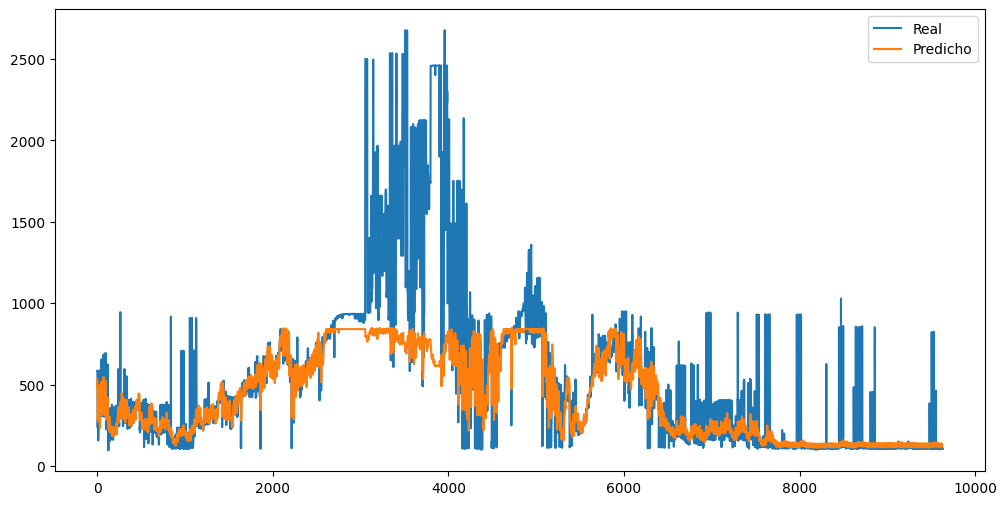

In [50]:
# ============================
# 7. Graphic
# ============================

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.legend()
plt.show()